In [2]:
!wget -O trace.csv.gz https://github.com/Azure/AzurePublicDataset/raw/master/data/AzureLMMInferenceTrace_multimodal.csv.gz


--2026-03-18 18:32:50--  https://github.com/Azure/AzurePublicDataset/raw/master/data/AzureLMMInferenceTrace_multimodal.csv.gz
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/Azure/AzurePublicDataset/master/data/AzureLMMInferenceTrace_multimodal.csv.gz [following]
--2026-03-18 18:32:51--  https://raw.githubusercontent.com/Azure/AzurePublicDataset/master/data/AzureLMMInferenceTrace_multimodal.csv.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8524196 (8.1M) [application/octet-stream]
Saving to: ‘trace.csv.gz’

trace.csv.gz        100%[===================>]   8.13M  30.3MB/s    in 0.3s    

2

Найдем минимальное N гпу, с учетом SLA. Так как возникла проблема c long tail latency и стадия Prefill тяжеловесная, то будем считать,

---

что минимальное число ГПУ удовлетворяет метрике ttft 90ый перцентиль + все перцентили на стадию decode


Предварительный анализ логов:

Columns: ['TIMESTAMP', 'NumImages', 'ContextTokens', 'GeneratedTokens']
--------------------
                  TIMESTAMP  NumImages  ContextTokens  GeneratedTokens
0  2024-10-15T12:00:00.269Z          0            770              491
1  2024-10-15T12:00:05.819Z          1            949              126
2  2024-10-15T12:00:06.513Z          1            964               79
3  2024-10-15T12:00:07.332Z          0             78                5
4  2024-10-15T12:00:07.566Z          1           1724               28
5  2024-10-15T12:00:07.566Z          1            946               11
6  2024-10-15T12:00:07.623Z          0            913              370
7  2024-10-15T12:00:07.813Z          1            931               86
8  2024-10-15T12:00:08.415Z          0           1195                1
9  2024-10-15T12:00:08.535Z          0           1332              508
Данные готовы для симулятора:
   Arrival_Sec  NumImages  ContextTokens  GeneratedTokens
0        0.000          0            7

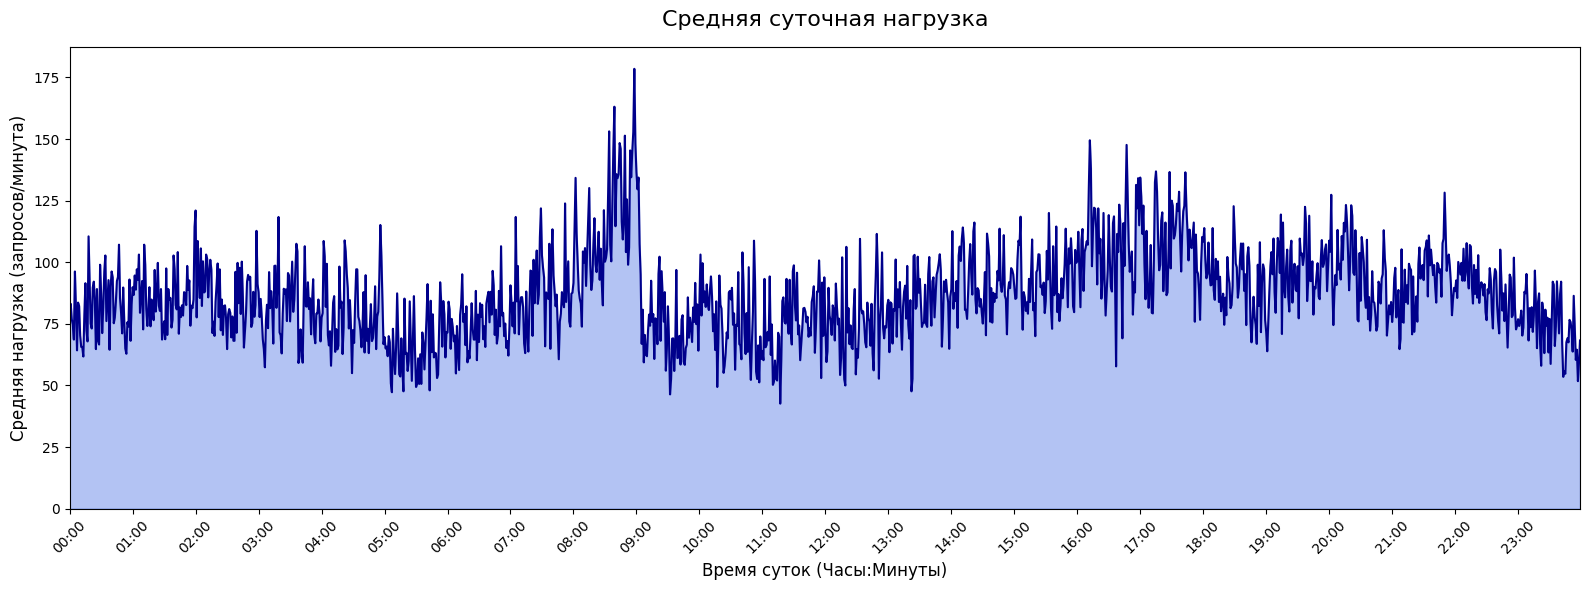

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# gzip по расширению
df_ = pd.read_csv('trace.csv.gz', compression='gzip')

df = df_
print("Columns:", df.columns.tolist())
print("-" * 20)
print(df.head(10))

df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])

# Берем время самого первого запроса
start_time = df['TIMESTAMP'].min()

# Считаем разницу в секундах (с долями миллисекунд)
df['Arrival_Sec'] = (df['TIMESTAMP'] - start_time).dt.total_seconds()
print("Данные готовы для симулятора:")
print(df[['Arrival_Sec', 'NumImages', 'ContextTokens', 'GeneratedTokens']].head())

df['Time_HHMM'] = df['TIMESTAMP'].dt.strftime('%H:%M')

# сколько запросов вообще, если бин это каждая минута всех дней
total_per_minute = df.groupby('Time_HHMM').size()

#кол-во дней
num_days = df['TIMESTAMP'].dt.normalize().nunique()

avg_per_minute = total_per_minute / num_days

plt.figure(figsize=(16,6))

plt.fill_between(avg_per_minute.index, avg_per_minute.values,
                 color = 'royalblue', alpha=0.4)
plt.plot(avg_per_minute.index, avg_per_minute.values, color='darkblue',
         linewidth=1.5)
plt.title('Средняя суточная нагрузка', fontsize=16, pad=15)
plt.xlabel('Время суток (Часы:Минуты)', fontsize=12)
plt.ylabel('Средняя нагрузка (запросов/минута)', fontsize=12)


# выводим каждые 60 минут
plt.xticks(np.arange(0, len(avg_per_minute), 60), rotation=45)
# границы графика от 00:00 до 23:59
plt.xlim(avg_per_minute.index[0], avg_per_minute.index[-1])
plt.ylim(bottom=0) # Ось Y всегда должна начинаться с нуля

plt.tight_layout()
plt.show()

In [4]:
df_.head(5)

,TIMESTAMP,NumImages,ContextTokens,GeneratedTokens,Arrival_Sec,Time_HHMM
0,2024-10-15 12:00:00.269000+00:00,0,770,491,0.000,12:00
1,2024-10-15 12:00:05.819000+00:00,1,949,126,5.550,12:00
2,2024-10-15 12:00:06.513000+00:00,1,964,79,6.244,12:00
3,2024-10-15 12:00:07.332000+00:00,0,78,5,7.063,12:00
4,2024-10-15 12:00:07.566000+00:00,1,1724,28,7.297,12:00


Возьмем время с 16.00 до 16.30 второго дня логов, так как оно репрезентативно и имеет примерно 5000 сэмплов, что недолго для GridSearch, если больше, то колаб долго считает

Наша задача подобрать MAX_CHUNK_SIZE И MAX_BATCH_SIZE под спеки видеокарты

In [5]:
df['TIMESTAMP'] = pd.to_datetime(df['TIMESTAMP'])

# Получаем список уникальных дат, отсортированных по возрастанию
unique_dates = df['TIMESTAMP'].dt.date.sort_values().unique()

if len(unique_dates) > 1:
    second_day = unique_dates[1] # Индекс 1 — это второй день
    print(f"Выбран второй день для анализа: {second_day}")

    # 2. Создаем удобную колонку со временем (часы и минуты)
    df['Time_HHMM'] = df['TIMESTAMP'].dt.strftime('%H:%M')

    # 3. Делаем двойную маску: совпадение по дате И совпадение по времени
    mask_date = (df['TIMESTAMP'].dt.date == second_day)
    mask_time = (df['Time_HHMM'] >= '16:00') & (df['Time_HHMM'] <= '16:30')

    # 4. Применяем обе маски и копируем кусок датафрейма
    df_peak = df[mask_date & mask_time].copy()

    # 5. КРИТИЧЕСКИ ВАЖНО: Пересчитываем Arrival_Sec
    # Теперь 0-я секунда симуляции — это ровно 16:00 (или время первого лога в этот час)
    peak_start_time = df_peak['TIMESTAMP'].min()
    df_peak['Arrival_Sec'] = (df_peak['TIMESTAMP'] - peak_start_time).dt.total_seconds()

    print(f"Отобрано {len(df_peak)} запросов за {second_day} с 16:00 до 17:00.")
    print("-" * 40)
    print(df_peak[['TIMESTAMP', 'Arrival_Sec', 'NumImages', 'ContextTokens', 'GeneratedTokens']].head())

else:
    print("Ошибка: В датасете меньше двух дней логов.")

Выбран второй день для анализа: 2024-10-16
Отобрано 4910 запросов за 2024-10-16 с 16:00 до 17:00.
----------------------------------------
                              TIMESTAMP  Arrival_Sec  NumImages  \
203977 2024-10-16 16:00:02.564000+00:00        0.000          0   
203978 2024-10-16 16:00:02.678000+00:00        0.114          0   
203979 2024-10-16 16:00:02.820000+00:00        0.256          1   
203980 2024-10-16 16:00:03.107000+00:00        0.543          1   
203981 2024-10-16 16:00:03.568000+00:00        1.004          1   

        ContextTokens  GeneratedTokens  
203977            326              811  
203978            163               11  
203979           2686              437  
203980           1895              155  
203981           2686              413  


In [6]:
df_peak.shape

(4910, 6)

### Logic simulation  (см. task_huawei.py)

Hyperparametrs

In [29]:
MEM_M = 80000  # 80 gb memory
MEM_MODEL_TEXT_EXTRACTION = 600  # MB  weights для самой модели детекцим
MEM_M -= MEM_MODEL_TEXT_EXTRACTION

MEM_X = 10  # вес самой картинки 1024px
MEM_Y = 1  # мб на 1 токен контекста (входной текст)
MEM_Z = 1  # мб на 1 сгенерированный токен ( выходной текст)
# ТОКЕНЫ контекста и генерации разные вещи и хранятся в VRAM

# compute_costs на препроцессинг картинки, обработку токена, время генерации 1 токена
COST_A = 0.5  # на картинку
COST_B = 0.01  # обработка 1 токена контекста
COST_C = 0.05  # 1 сгенерированный токен

# limitations global contants
LIM_TTFT = 10  # P ttft not more P
LIM_GEN_NEXT_TOK = 1  # D limit time stage 3 0.05 это sec/token


In [8]:
# @title
import heapq
import math
from collections import deque


df = df_peak

class Request:
    """
    Поля: id, время_прибытия, кол_во_картинок, токены_контекста, токены_генерации
    То что содержится в классе:
    id - запроса
    start_processing_time - время когда gpu только НАЧАЛА работать
    ttft_time - закончился препроцессинг картинок и контекста
    finish_time - время сгенерированного последнего токена, который должен <= T (по ТЗ)
    limit_failed - флаг нарушение одно из требований по тз
    time_stage_3 - время до последнего токена
    max_gen_tokens - сколько у самого жирного реквеста будет токенов для генерации в батче
    request берез из df[['Arrival_Sec', 'ContextTokens', 'NumImages', 'GeneratedTokens']]

    """

    def __init__(self, id, time_to_come, token_context, num_images, token_generation):
        self.id = id
        self.time_to_come = time_to_come
        self.num_images = num_images
        self.token_context = token_context
        self.token_generation = token_generation

        # данные симуляции
        self.start_processing_time = None
        self.ttft_time = None

        self.images_left = self.num_images
        self.context_tokens_left = self.token_context
        self.tokens_left_to_generate = (
            self.token_generation
        )  # сколько осталось генерить
        self.allocated_vram = 0  # сколько памяти запрос схавал

        self.finish_time = None
        self.limit_failed = False
        self.time_stage_3 = None
        self.fail_reason = None

    def get_memory_per_request(self):
        """
        сколько инпут займет памяти VRAM
        для картинки, контекстов, генераций
        одного реквеста
        """
        memory_images = self.num_images * MEM_X
        memory_context = self.token_context * MEM_Y
        memory_generation = self.token_generation * MEM_Z
        return memory_images + memory_context + memory_generation


class Accelerator:
    """
    класс GPU c характеристиками
    статус (Свободен/Занят), доступная_память, вычислительная_мощность, номер_гпу
    """

    def __init__(self, status, memory, computing, gpu_id):
        self.status = status
        self.free_memory = MEM_M
        self.computing = computing
        self.active_batch = []  # наша VRAM
        self.is_ticking = (
            False  # это флаг того, что если загрузится гпу, то она в работе
        )
        self.gpu_id = gpu_id
        self.total_compute_time = 0.0


class Event:
    """
    класс события
    Поля: время_события, тип_события
    data - весь экземляр класса Accelerator
    list_current_batch - лист всех нынешнего батча
    """

    def __init__(self, time_event, type_event, data, list_current_batch=None):
        self.time_event = time_event
        self.type_event = type_event
        self.data = data
        self.list_current_batch = list_current_batch

    # для сравнения событий через магическиий метода __less than__
    def __lt__(self, other):
        return self.time_event < other.time_event


def make_heap_from_df(df):

    scheduler_event = []
    # берем сырой df
    df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"])

    # Берем время самого первого запроса
    start_time = df["TIMESTAMP"].min()

    # Считаем разницу в секундах (с долями миллисекунд)
    df["Arrival_Sec"] = (df["TIMESTAMP"] - start_time).dt.total_seconds()
    # если не отсортированно изначально
    df.sort_values(by="TIMESTAMP", inplace=True)

    # из дата фрейма в инициализацию календаря
    for row in df[
        ["Arrival_Sec", "ContextTokens", "NumImages", "GeneratedTokens"]
    ].itertuples():
        req = Request(
            row.Index,
            row.Arrival_Sec,
            row.ContextTokens,
            row.NumImages,
            row.GeneratedTokens,
        )

        event = Event(req.time_to_come, "NEW REQUEST", req)
        scheduler_event.append(event)

    # подаем лист, делает все на месте, лист теперь куча
    heapq.heapify(scheduler_event)
    return scheduler_event


def check_limitations(req):
    """
    проверка sla с подробным логированием

    """
    ttft_duration = req.ttft_time - req.time_to_come
    average_time_per_token = 0.0

    print(
        f"[LOG SLA CHECK] Req {req.id}: TTFT = {ttft_duration:.2f}s (Limit {LIM_TTFT}) | "
        f"Decode Avg = {average_time_per_token:.4f}s (Limit {LIM_GEN_NEXT_TOK}) | "
        f"Gen Tokens = {req.token_generation}"
    )
    if ttft_duration > LIM_TTFT:
        req.limit_failed = True
        req.fail_reason = "TTFT"
        print(f"   -----> [SLA FAILED] REQ {req.id}: ПРЕВЫШЕН ЛИМИТ TTFT!")
    if req.token_generation > 0:
        total_stage_3_time = req.finish_time - req.ttft_time
        average_time_per_token = total_stage_3_time / req.token_generation
        if average_time_per_token > LIM_GEN_NEXT_TOK:
            req.limit_failed = True
            req.fail_reason = "DECODE"
            print(
                f" ----> [SLA FAILED] REQ {req.id}: ПРЕВЫШЕН ЛИМИТ ГЕНЕРАЦИИ НА ТОКЕН"
            )



def scheduler_step(
    time_now, deque_requests, accelerator, scheduler_event, completed_requests
):

    finished_requests = []

    for req in accelerator.active_batch:
        if req.tokens_left_to_generate == 0 and req.ttft_time is not None:
            req.finish_time = time_now
            req.time_stage_3 = req.finish_time - req.ttft_time
            accelerator.free_memory += req.allocated_vram
            check_limitations(req)
            finished_requests.append(req)

    finished_set = set(finished_requests)
    completed_requests.extend(finished_requests)
    accelerator.active_batch = [
        req for req in accelerator.active_batch if req not in finished_set
    ]

    # Дозаполнение батча (Continuous Batching)
    while deque_requests:
        # --- ПРЕДОХРАНИТЕЛЬ: Ограничение  батча ---
        if len(accelerator.active_batch) >= MAX_BATCH_SIZE:
            break

        next_req = deque_requests[0]
        tokens_for_first_chunk = min(MAX_CHUNK_SIZE, next_req.token_context)
        initial_mem_needed = (next_req.num_images * MEM_X) + (
            tokens_for_first_chunk * MEM_Y
        )

        if initial_mem_needed > MEM_M:
            deque_requests.popleft()
            continue

        if initial_mem_needed <= accelerator.free_memory:
            req = deque_requests.popleft()
            accelerator.active_batch.append(req)

            img_mem = req.images_left * MEM_X
            chunk_mem = tokens_for_first_chunk * MEM_Y

            total_reserved = img_mem + chunk_mem
            accelerator.free_memory -= total_reserved
            req.allocated_vram += total_reserved

            # Обнуляем картинки, так как память под них выделена
            req.images_left = 0
            # req.context_tokens_left -= tokens_for_first_chunk
        else:
            break

    # Если батч пуст - выключаем GPU
    if not accelerator.active_batch:
        accelerator.is_ticking = False
        return

    #  Распределение на Newbies (Prefill) и Decoders (Генерация)
    newbies = [i for i in accelerator.active_batch if i.ttft_time is None]
    # Защита от "путешествий во времени" (запрос становится декодером только когда настало его время)
    decoders = [k for k in accelerator.active_batch if k.ttft_time is not None]

    current_chunk_tokens = 0
    current_images_to_process = 0
    processed_decoders = 0

    # Обработка Prefill
    if newbies:
        for req in newbies:
            # Считаем картинки только один раз (когда контекст еще целый)
            if getattr(req, "images_processed", False) is False:
                current_images_to_process += req.num_images
                req.images_processed = True

            #  берем остаток токенов, но не больше чанка
            tokens_to_compute = min(req.context_tokens_left, MAX_CHUNK_SIZE)
            current_chunk_tokens += tokens_to_compute
            # списываем токены, которые взяли в вычисление
            req.context_tokens_left -= tokens_to_compute

            if req.context_tokens_left > 0:
                next_chunk = min(req.context_tokens_left, MAX_CHUNK_SIZE)
                mem_needed = next_chunk * MEM_Y

                if accelerator.free_memory >= mem_needed:
                    req.context_tokens_left -= next_chunk
                    accelerator.free_memory -= mem_needed
                    req.allocated_vram += mem_needed

            if current_chunk_tokens >= MAX_CHUNK_SIZE:
                break

    # Обработка Decode EVICTION POLICY
    for req in decoders:
        # защита от утечки памяти
        if req not in accelerator.active_batch:
            continue

        while accelerator.free_memory < MEM_Z:
            victim_req = max(
                accelerator.active_batch, key=lambda r: r.tokens_left_to_generate
            )
            if victim_req is req:
                break

            accelerator.free_memory += victim_req.allocated_vram
            victim_req.allocated_vram = 0
            victim_req.context_tokens_left = victim_req.token_context
            victim_req.ttft_time = None
            accelerator.active_batch.remove(victim_req)
            deque_requests.appendleft(victim_req)

        if accelerator.free_memory >= MEM_Z:
            req.tokens_left_to_generate -= 1
            accelerator.free_memory -= MEM_Z
            req.allocated_vram += MEM_Z
            processed_decoders += 1

    time_images = (
        COST_A * math.sqrt(current_images_to_process)
        if current_images_to_process > 0
        else 0
    )
    time_prefill = (
        COST_B * math.sqrt(current_chunk_tokens) if current_chunk_tokens > 0 else 0
    )
    time_decode = (
        COST_C * math.sqrt(processed_decoders) if processed_decoders > 0 else 0
    )

    step_time = time_images + time_prefill + time_decode

    # предохранитель от Deadlock
    if step_time <= 0:
        step_time = 0.001

    # подсчет полезной работы
    accelerator.total_compute_time += step_time

    # Назначаем TTFT тем, кто закончил префилл
    for req in newbies:
        if req.context_tokens_left == 0 and req.ttft_time is None:
            req.ttft_time = time_now + step_time

    #  Создаем следующее событие (ТАКТ ВЫПОЛНЕН)
    this_event = Event(
        time_event=time_now + step_time, type_event="TICK_DONE", data=accelerator
    )
    heapq.heappush(scheduler_event, this_event)
    accelerator.is_ticking = True


def simulate(N, df):
    """
    df - наши логи
    N - количество гпу
    """
    time_now = 0
    list_accelerators = [Accelerator("FREE ACCELERATOR", MEM_M, 1, i) for i in range(N)]

    deque_requests = deque()
    completed_requests = []  # успешно завершенные запросы

    # взяли и внесли в кучу запросы
    scheduler_event = make_heap_from_df(df)

    while scheduler_event:
        this_event = heapq.heappop(scheduler_event)
        time_now = this_event.time_event

        if this_event.type_event == "NEW REQUEST":
            print(
                f"\n[LOG TIME: {time_now:.2f}] Новый запрос в систему: Req {this_event.data.id} (INPUT_TOK: {this_event.data.token_context}, GEN_TOK: {this_event.data.token_generation})"
            )
            deque_requests.append(this_event.data)
            # Убрали цикл for acc in list_accelerators отсюда, перенесли вниз

        elif this_event.type_event == "TICK_DONE":
            this_accelerator = this_event.data
            scheduler_step(
                time_now,
                deque_requests,
                this_accelerator,
                scheduler_event,
                completed_requests,
            )

        # УНИВЕРСАЛЬНЫЙ БУДИЛЬНИК ДЛЯ GPU:
        # Если в очереди есть задачи, пытаемся скормить их всем свободным картам
        if deque_requests:
            for acc in list_accelerators:
                if not acc.is_ticking:
                    if len(deque_requests) > 0:
                        print(
                            f"[LOG TIME: {time_now:.2f}] Будильник активировал свободную GPU {acc.gpu_id}"
                        )
                        scheduler_step(
                            time_now,
                            deque_requests,
                            acc,
                            scheduler_event,
                            completed_requests,
                        )

    return True, completed_requests, list_accelerators


### End logic simulation

### Подберем параметры MAX_BATCH_SIZE, MAX_CHUNK_SIZE, GPU_COUNT через GridSearch с заданными гиперпараметрами

где:
- MAX_BATCH_SIZE - оптимальное кол-во реквестов, которое может взять ГПУ за один раз, уложиться в Service Limitation Agreements и для разбалансировки запросов из-за жадника
- MAX_CHUNK_SIZE - оптимальное количество токенов (контектсных и сгенерированных) которое может взять на себя одна ГПУ за 1 forwards pass чтобы соблюсти ограничения SLA. Реализован Chunked Prefill и [MAX_CHUNK_SIZE] нужно подстраивать под спеки ГПУ, поэтому его тоже считаем

В конце отпута работы нижней ячейки представлен информативный график

Streaming output truncated to the last 5000 lines.
[LOG SLA CHECK] Req 207041: TTFT = 2.52s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 460
[LOG SLA CHECK] Req 207149: TTFT = 1.23s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 366
[LOG SLA CHECK] Req 207162: TTFT = 2.07s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 356
[LOG SLA CHECK] Req 206995: TTFT = 1.11s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 465
[LOG SLA CHECK] Req 207284: TTFT = 0.44s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 74

[LOG TIME: 1122.20] Новый запрос в систему: Req 207308 (INPUT_TOK: 729, GEN_TOK: 59)
[LOG SLA CHECK] Req 206982: TTFT = 1.11s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 490
[LOG SLA CHECK] Req 207290: TTFT = 0.85s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 43

[LOG TIME: 1122.71] Новый запрос в систему: Req 207309 (INPUT_TOK: 1967, GEN_TOK: 920)
[LOG SLA CHECK] Req 207058: TTFT = 2.50s (Limit 1

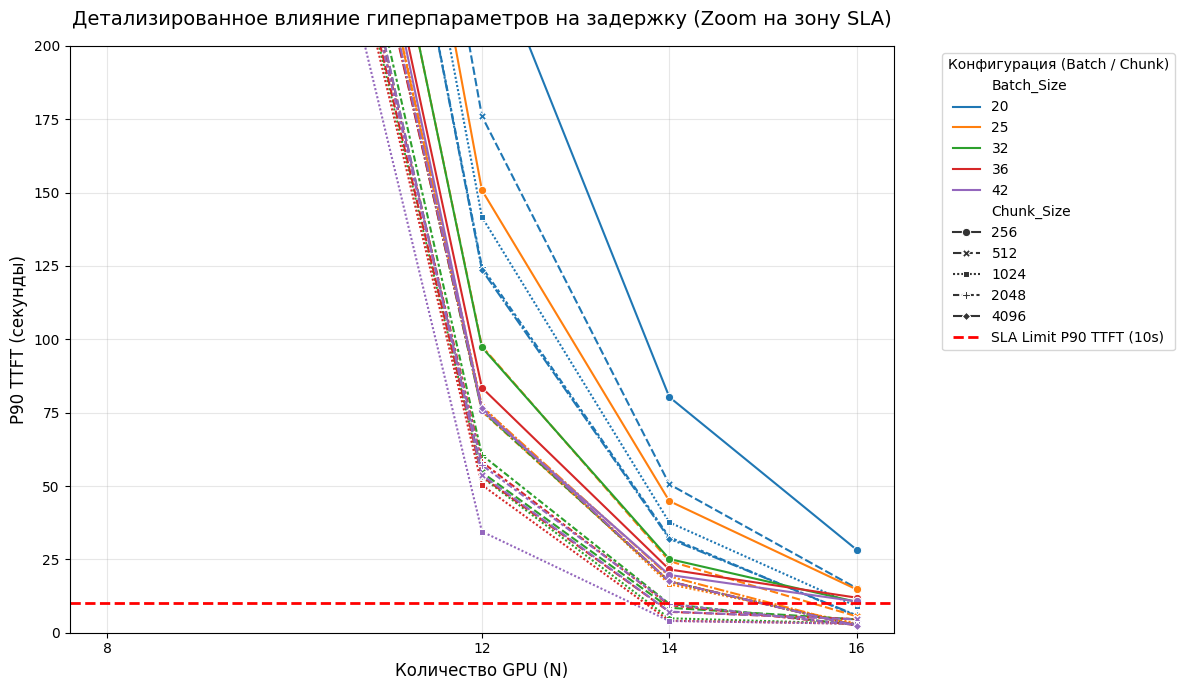

In [11]:
# @title
import itertools
# Сетка гиперпараметров для перебора
chunk_sizes = [256, 512, 1024, 2048, 4096]
batch_sizes = [20, 25, 32, 36, 42]
gpu_counts = [8, 11, 12, 14, 16]

results = []

print(f"\nЗапуск 3D Grid Search. Проверяем {len(gpu_counts) * len(chunk_sizes) * len(batch_sizes)} комбинаций...")

for N, chunk, batch in itertools.product(gpu_counts, chunk_sizes, batch_sizes):

    # Обновляем глобальные параметры для симулятора
    MAX_CHUNK_SIZE = chunk
    MAX_BATCH_SIZE = batch

    # Запускаем симуляцию
    success, completed, _ = simulate(N, df_peak.copy())


    #  TTFT
    ttft_times = [(req.ttft_time - req.time_to_come) for req in completed if req.ttft_time is not None]
    p90_ttft = np.percentile(ttft_times, 90) if ttft_times else 999.0

    #  Decode Time (Время на генерацию 1 токена)
    decode_times = [
        (req.time_stage_3 / req.token_generation)
        for req in completed
        if req.finish_time is not None and req.token_generation > 0
    ]
    p99_decode = np.percentile(decode_times, 99) if decode_times else 999.0

    # Проверка SLA (лимиты берем из твоих констант: LIM_TTFT = 10, LIM_GEN_NEXT_TOK = 1)
    sla_passed = (p90_ttft <= LIM_TTFT) and (p99_decode <= LIM_GEN_NEXT_TOK)

    # Собираем данные в память, а не в консоль
    results.append({
        'N_GPUs': N,
        'Chunk_Size': chunk,
        'Batch_Size': batch,
        'P90_TTFT': p90_ttft,
        'P99_Decode': p99_decode,
        'SLA_Passed': sla_passed
    })

#  АНАЛИТИКА И ВИЗУАЛИЗАЦИЯ

results_df = pd.DataFrame(results)

# СОРТИРОВКА И ВЫВОД ТОП КОНФИГУРАЦИЙ ---
# Сортируем сначала по успешности SLA, затем по минимальному P90_TTFT, затем по минимальному N
sorted_df = results_df.sort_values(
    by=['SLA_Passed','N_GPUs', 'P90_TTFT'],
    ascending=[False, True, True]
)

print("\n" + "="*70)
print(" ТОП-10 ЛУЧШИХ КОНФИГУРАЦИЙ ПО P90 TTFT:")
print("="*70)
# Выводим красивую таблицу без лишних индексов
print(sorted_df[['N_GPUs', 'Chunk_Size', 'Batch_Size', 'P90_TTFT', 'P99_Decode', 'SLA_Passed']].head(10).to_string(index=False))
print("="*70)

# Поиск минимального N (основная задача ТЗ)
successful_configs = results_df[results_df['SLA_Passed'] == True]
if not successful_configs.empty:
    min_n = successful_configs['N_GPUs'].min()
    print(f"\n ОТВЕТ: Минимальное количество GPU для выполнения SLA: {min_n}")
else:
    print("\n ВНИМАНИЕ: Ни одна конфигурация не уложилась в SLA. Все значения выше красной линии.")

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=results_df,
    x='N_GPUs',
    y='P90_TTFT',
    hue='Batch_Size',
    style='Chunk_Size',
    markers=True,
    palette='tab10'
)

plt.axhline(LIM_TTFT, color='red', linestyle='--', linewidth=2, label=f'SLA Limit P90 TTFT ({LIM_TTFT}s)')

# Ограничиваем ось Y для читаемости, если не видно, то рекомендую 100 поставить или 300
plt.ylim(0, 150)

plt.xticks(sorted(results_df['N_GPUs'].unique()))

plt.title('Детализированное влияние гиперпараметров на задержку', fontsize=14, pad=15)
plt.xlabel('Количество GPU (N)', fontsize=12)
plt.ylabel('P90 TTFT (секунды)', fontsize=12)

# Убираем легенду за пределы графика, чтобы она не перекрывала линии
plt.legend(title='Конфигурация (Batch / Chunk)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Считается  3-4 минуты

Самые лучшие конфигурации видеокарты:

In [14]:
results_df[results_df['SLA_Passed'] == True].head(10)

,N_GPUs,Chunk_Size,Batch_Size,P90_TTFT,P99_Decode,SLA_Passed
57,14,512,32,8.503249,0.696418,True
58,14,512,36,7.110738,0.713879,True
59,14,512,42,7.200773,0.754960,True
62,14,1024,32,4.925468,0.698340,True
63,14,1024,36,4.080272,0.737635,True
64,14,1024,42,3.986565,0.778943,True
67,14,2048,32,9.847126,0.639511,True
68,14,2048,36,9.394640,0.729957,True
69,14,2048,42,9.723782,0.715332,True
81,16,512,25,5.577001,0.594873,True


заметим, что на 64 индексе очень хороший спек: 14 гпу, 1024 chunk_size, 42 Batch_size - метрика 90го перцентиля для P90_TTFT ниже 4 секунд, когда по SLA целых 10 секунд на stage1 + stage2!!!

In [22]:
results_df.to_csv('filename.csv', index = False)

### Сравним полученный результат с теоретическими пределами (t_best, t_worst), вдруг алгоритм делает то, что невозможно


### Theoretical Bounds for Inference (Discrete Event Simulation)

Пусть $\mathbb{N}$ — множество запросов в батче, $C_{img}, C_{ctx}, C_{gen}$ — константы стоимости $A, B, C$. Размер текущего батча: $B$

##### 1. Lower Bound (Теоретический минимум времени / Best Case)
Достигается при идеальном заполнении батча ($B = B_{max}$) и отсутствии провалов по памяти. Эвристика квадратного корня дает максимальное ускорение на единицу вычислений:$$T_{best} = \frac{ \sum_{i=1}^{B_{max}} (C_{img} \cdot I_i + C_{ctx} \cdot K_i + C_{gen} \cdot G_i) }{ \sqrt{B_{max}} }$$Где $I, K, G$ — кол-во изображений, токенов префилла и генерации.
##### 2. Upper Bound (Теоретический максимум / Worst Case)Достигается при деградации планировщика до последовательной обработки (Sequential Processing, $B = 1$), например, когда запросы настолько огромны по памяти (OOM), что в $VRAM$ влезает только один запрос:$$T_{worst} = \sum_{i \in \mathbb{R}} \left( \frac{ C_{img} \cdot I_i + C_{ctx} \cdot K_i + C_{gen} \cdot G_i }{ \sqrt{1} } \right) = \sum_{i} Cost_i$$

##### 3. Pipeline Bubble / Idle Penalty

Время простоя оборудования $\Delta T_{idle}$ возникает, когда интервал между запросами $\lambda$ превышает время вычисления предыдущего батча $T_{step}$:$$Utilization = 1 - \frac{ \sum \Delta T_{idle} }{ T_{total\_sim} }$$Мой scheduler_step с алгоритмом Continuous Batching минимизирует $T_{max}$, смещая реальное время исполнения ближе к $T_{min}$.

In [30]:
# выбор лучшего из десятки.
best_config = results_df.iloc[64]

best_N = int(best_config['N_GPUs'])
best_chunk = int(best_config['Chunk_Size'])
best_batch = int(best_config['Batch_Size'])
best_p90 = best_config['P90_TTFT']

T_worst, T_best для 1_000_000 логов (всего датасета)

In [39]:
df_['Req_Cost'] = (
    COST_A * df_['NumImages'] +
    COST_B * df_['ContextTokens'] +
    COST_C * df_['GeneratedTokens']
)
t_worst = df_['Req_Cost'].sum() / np.sqrt(1)

t_best = t_worst / np.sqrt(best_chunk)

print(f" T_worst (Worst Case, B=1)     = {t_worst:,.2f} машино-секунд")
print(f" T_best (Best Case, B={best_chunk})   = {t_best:,.2f} машино-секунд")


 T_worst (Worst Case, B=1)     = 45,607,213.29 машино-секунд
 T_best (Best Case, B=1024)   = 1,425,225.42 машино-секунд


t_real (см. код в task_huawei.py - он также работает, но лучше оформлен (не хватило времени докинуть сюда, вставил рабочий, но без типов и с огромной def scheduler_step, которую в task_huawei.py я распилил)
- на всём количестве логов 1_000_000 штук


In [32]:
MAX_CHUNK_SIZE = best_chunk
MAX_BATCH_SIZE = best_batch

In [33]:
# @title
def run_analytics(N, df_sample):

    success, completed_requests, accelerators = simulate(N, df_sample.copy())

    total_reqs = len(completed_requests)
    if total_reqs == 0:
        print("Симуляция не вернула ни одного запроса.")
        return

    failed_reqs = [req for req in completed_requests if req.limit_failed]
    failed_count = len(failed_reqs)
    fail_rate = (failed_count / total_reqs) * 100

    print(f"\n{'=' * 50}")
    print(f"ЗАПУСК СИМУЛЯЦИИ: N (Кол-во GPU) = {N}")
    print(f"1_000_000 логов:")
    print(f"MAX_CHUNK_SIZE: = {MAX_CHUNK_SIZE}")
    print(f"MAX_BATCH_SIZE = {MAX_BATCH_SIZE} сколько макс рекв в батч")
    print(f"{'=' * 50}")

    print("\n--- БАЗОВАЯ СТАТИСТИКА ---")
    print(f"Всего запросов обработано: {total_reqs}")
    print(f"Провалено по SLA: {failed_count} ({fail_rate:.2f}%)")

    # Собираем сырые данные для перцентилей
    ttft_times = [
        (req.ttft_time - req.time_to_come)
        for req in completed_requests
        if req.ttft_time is not None
    ]
    decode_times = [
        (req.time_stage_3 / req.token_generation)
        for req in completed_requests
        if req.finish_time is not None and req.token_generation > 0
    ]

    if ttft_times:
        print("\n--- АНАЛИТИКА TTFT (Time To First Token) ---")
        print(f"Лимит SLA (P): {LIM_TTFT} сек")
        print(f"Среднее: {np.mean(ttft_times):.4f} сек")
        print(f"Медиана (P50): {np.percentile(ttft_times, 50):.4f} сек")
        print(f"P90: {np.percentile(ttft_times, 90):.4f} сек")
        print(f"P99: {np.percentile(ttft_times, 99):.4f} сек")
        print(f"Максимум: {np.max(ttft_times):.4f} сек")

    if decode_times:
        print("\n--- АНАЛИТИКА DECODE (Время на 1 токен генерации) ---")
        print(f"Лимит SLA (D): {LIM_GEN_NEXT_TOK} сек")
        print(f"Среднее: {np.mean(decode_times):.4f} сек")
        print(f"Медиана (P50): {np.percentile(decode_times, 50):.4f} сек")
        print(f"P90: {np.percentile(decode_times, 90):.4f} сек")
        print(f"P99: {np.percentile(decode_times, 99):.4f} сек")
        print(f"Максимум: {np.max(decode_times):.4f} сек")

    actual_makespan = max(req.finish_time for req in completed_requests if req.finish_time is not None)

    print("\n--- УТИЛИЗАЦИЯ И ПРОСТОЙ GPU (EMPIRICAL IDLE TIME) ---")
    total_idle_cluster = 0
    total_compute_cluster = 0

    for acc in accelerators:
        compute_time = acc.total_compute_time
        idle_time = actual_makespan - compute_time
        utilization = (compute_time / actual_makespan) * 100

        total_idle_cluster += idle_time
        total_compute_cluster += compute_time
        # Можно раскомментировать, чтобы посмотреть каждую карту отдельно:
        print(f"GPU {acc.gpu_id}: Утилизация {utilization:.1f}% | Работа: {compute_time:.1f}s | Простой: {idle_time:.1f}s")

    avg_cluster_utilization = (total_compute_cluster / (actual_makespan * N)) * 100
    print(f"Средняя загрузка кластера (Useful Compute): {avg_cluster_utilization:.2f}%")
    last_arrival_sec = max(req.time_to_come for req in completed_requests)
    # tail_processing_time = actual_makespan - last_arrival_sec
    # Считаем общую емкость кластера (N видеокарт работали actual_makespan секунд)
    total_cluster_capacity = actual_makespan * N

    # Выводим корректное соотношение:
    print(f"Суммарный простой кластера (Idle Time): {total_idle_cluster:,.2f} сек из общих {total_cluster_capacity:,.2f} машино-секунд")
        # Базовая логика рекомендаций
    print("\n--- РЕКОМЕНДАЦИИ  --")
    if fail_rate == 0:
        print("Система работает идеально. Ресурсов достаточно.")
    else:
        # Пытаемся понять, где узкое горлышко
        ttft_fails = sum(1 for t in ttft_times if t > LIM_TTFT)
        decode_fails = sum(1 for d in decode_times if d > LIM_GEN_NEXT_TOK)

        if ttft_fails > decode_fails:
            print(" Диагноз: Проблема на этапе Prefill (превышен TTFT).")
            print(
                " Рекомендация: Запросы слишком долго ждут в очереди. Необходимо увеличить количество GPU (N)."
            )
        else:
            print("Диагноз: Проблема на этапе Decode (долгая генерация).")
            print(
                " Рекомендация: Слишком большой батч на генерации, из-за чего падает скорость. Возможно, стоит уменьшить MAX_CHUNK_SIZE или увеличить вычислительную мощность (COST_C)."
            )

In [34]:
run_analytics(N=best_N, df_sample=df_)

Streaming output truncated to the last 5000 lines.

[LOG TIME: 604284.09] Новый запрос в систему: Req 998405 (INPUT_TOK: 112, GEN_TOK: 21)
[LOG SLA CHECK] Req 998326: TTFT = 0.42s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 378

[LOG TIME: 604284.94] Новый запрос в систему: Req 998406 (INPUT_TOK: 6398, GEN_TOK: 10)

[LOG TIME: 604285.45] Новый запрос в систему: Req 998407 (INPUT_TOK: 2788, GEN_TOK: 144)

[LOG TIME: 604285.81] Новый запрос в систему: Req 998408 (INPUT_TOK: 4562, GEN_TOK: 195)

[LOG TIME: 604285.95] Новый запрос в систему: Req 998409 (INPUT_TOK: 3392, GEN_TOK: 252)
[LOG SLA CHECK] Req 998402: TTFT = 0.69s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 47
[LOG SLA CHECK] Req 998364: TTFT = 1.41s (Limit 10) | Decode Avg = 0.0000s (Limit 1) | Gen Tokens = 224

[LOG TIME: 604286.06] Новый запрос в систему: Req 998410 (INPUT_TOK: 4544, GEN_TOK: 319)
[LOG TIME: 604286.06] Будильник активировал свободную GPU 3
[LOG SLA CHECK] Req 998393: TTFT = 10.53s

Считалось 7 минут
Результаты:


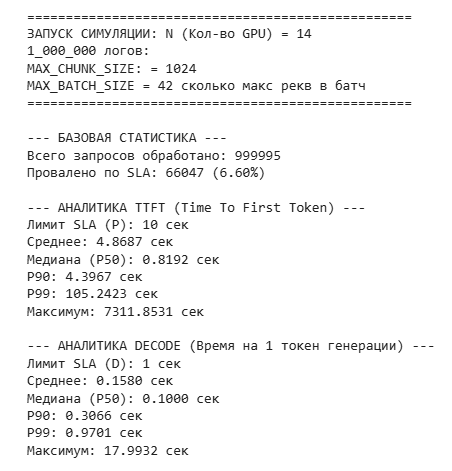

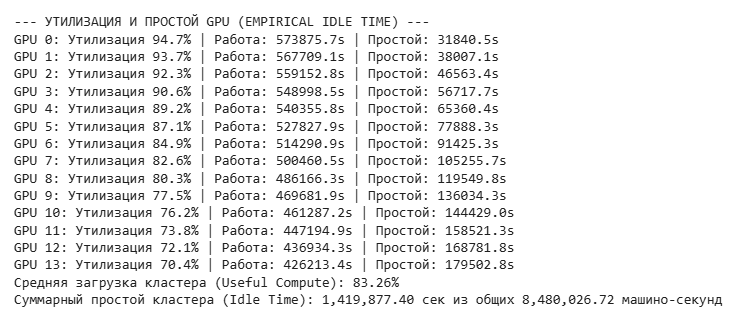

Вывод:

Требуется минимально 14 ГПУ, где

спеки:
- VRAM = 80GB
- COST_A = 0.5  # на картинку
- COST_B = 0.01  # обработка 1 токена контекста
- COST_C = 0.05  # 1 сгенерированный токен


- в среднем считалось ttft на миллион запросов = 4.8687 сек
- в среднем от ttft до полноценного ответа (decode = stage1 + stage2) = 0.1580 сек
Общее время на миллион логов = (4.8687 + 0.1580) * 1кк = 5_026_700 секунд

Когда в нижний предел = 1_425_225 секунд
А верхний = 45_607_213 секунд

Эмпирические результаты показали хорошие метрики, в том числе маленькое время простоя, так как в Discrete Event Simulator было по ходу развития имплементировано симуляции вот этих идей:
- Continious Batching
- Chunked Prefill
- KV-cache (легкое подобие) ((иначе расчет был для каждого слоя, а ещё один гиперпараметр это ещё больше усложнений))
- Eviction Policy

